In [7]:
import geopandas as gpd
from matplotlib import pyplot as plt

import matplotlib.colors as mcolors

import requests
import numpy as np
import io

import os
from dotenv import load_dotenv

load_dotenv()

INITIAL_BDA_PATH = os.getenv("INITIAL_BDA_PATH")


In [10]:
new = gpd.read_parquet("base_asset.parquet")

In [11]:
expected = gpd.read_file("/home/nathan/Desktop/BDA_integration/data/gpkgs/bda_2024_patches_2024_classified.gpkg", use_arrow=True, engine="pyogrio")


In [12]:
expected.total_bounds

array([-5.11664757, 41.36816244,  9.56685474, 51.07628151])

In [13]:
new.total_bounds

array([-5.11664757, 41.36816244,  9.56685474, 51.07628151])

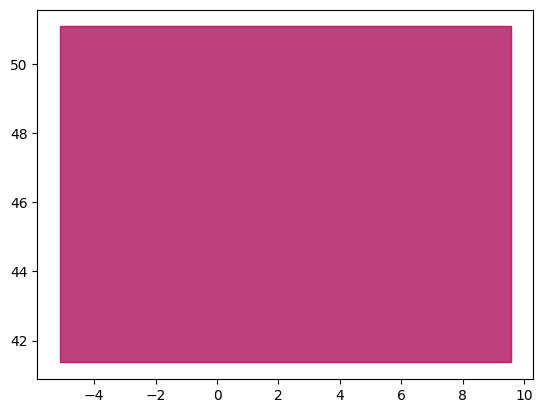

In [14]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon
import shapely

expected_poly = shapely.geometry.box(*expected.total_bounds)
new_poly = shapely.geometry.box(*new.to_crs("EPSG:4326").total_bounds)
fig, ax = plt.subplots()
plot_polygon(expected_poly, ax=ax, add_points=False, color='blue', alpha=0.5)
plot_polygon(new_poly, ax=ax, add_points=False, color='red', alpha=0.5)

In [15]:
(len(new), len(expected))

(603564, 603564)

In [16]:
(len(new["tile"].unique()), len(expected["tile"].unique()))

(31, 31)

<Axes: >

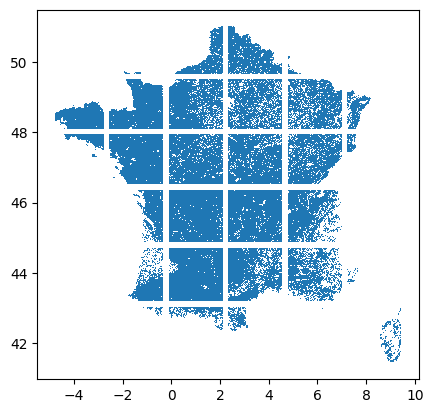

In [17]:
new[new["tile"] != -1].plot()

In [18]:
new

,patch_i,patch_j,geometry,hedgerows,fold,tile,aez_class,mst_class,thz_class
0,0,872,"POLYGON ((-5.10515 48.45542, -5.10515 48.46305...","LINESTRING (-5.116648 48.460143, -5.116593 48....",2,-1,"Sub-tropics, mod. cool; sub-humid, with soil/t...",225-270 days,"TRC4: Subtropics, moderately cool"
1,2,872,"POLYGON ((-5.08215 48.45542, -5.08215 48.46305...","MULTILINESTRING ((-5.092712 48.455643, -5.0926...",2,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"
2,3,872,"POLYGON ((-5.07065 48.45542, -5.07065 48.46305...","MULTILINESTRING ((-5.080747 48.457216, -5.0807...",2,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"
3,28,860,"POLYGON ((-4.78319 48.36383, -4.78319 48.37147...","LINESTRING (-4.783251 48.365696, -4.783193 48....",2,6,Land with severe soil/terrain limitations,270-365 days,"TRC5: Subtropics, cool"
4,28,865,"POLYGON ((-4.78319 48.40201, -4.78319 48.40965...","MULTILINESTRING ((-4.783505 48.409166, -4.7831...",2,6,"Sub-tropics, cool; humid, with soil/terrain li...",270-365 days,"TRC5: Subtropics, cool"
...,...,...,...,...,...,...,...,...,...
603559,1275,107,"POLYGON ((9.55536 42.28494, 9.55536 42.29345, ...","MULTILINESTRING ((9.550783 42.284943, 9.550778...",0,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"
603560,1275,108,"POLYGON ((9.55536 42.29345, 9.55536 42.30195, ...","MULTILINESTRING ((9.552227 42.293658, 9.552249...",0,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"
603561,1275,109,"POLYGON ((9.55536 42.30195, 9.55536 42.31046, ...","MULTILINESTRING ((9.546016 42.302641, 9.546164...",0,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"
603562,1275,110,"POLYGON ((9.55536 42.31046, 9.55536 42.31896, ...","MULTILINESTRING ((9.544366 42.310879, 9.544419...",0,-1,"Sub-tropics, mod. cool; sub-humid, no soil/ter...",225-270 days,"TRC4: Subtropics, moderately cool"


In [20]:
len(expected)

603564

In [21]:
len(new)

603564

In [22]:
expected.total_bounds 

array([-5.11664757, 41.36816244,  9.56685474, 51.07628151])

In [23]:
new.total_bounds

array([-5.11664757, 41.36816244,  9.56685474, 51.07628151])

In [24]:
import shapely


new_total_bounds = shapely.geometry.box(*(new.to_crs(expected.crs).total_bounds))


In [25]:
expected_filtered = expected[expected.geometry.within(new_total_bounds)]

In [26]:
new_in_ex_crs = new.to_crs(expected.crs)

join_expected = expected[["geometry"]]
join_new = new_in_ex_crs[["geometry"]]
join_expected["preserved_geometry"] = join_expected.geometry
matches = gpd.sjoin(
    left_df=join_new,
    right_df=join_expected,
    how="inner",
    predicate="intersects"
)

In [27]:
len(matches)

3388788

In [28]:
matches.iloc[0]

geometry              POLYGON ((-5.105149129563549 48.45542262813023...
index_right                                                           0
preserved_geometry    POLYGON ((-5.116647565200277 48.45542262813023...
Name: 0, dtype: object

In [29]:
matches["intersection"] = matches.apply(
    lambda x: shapely.intersection(x.geometry, x["preserved_geometry"]).area,
    axis=1
)


In [30]:
matches["union"] = matches.apply(
    lambda x: shapely.union(x.geometry, x["preserved_geometry"]).area,
    axis=1
)

In [31]:
matches["iou"] = matches["intersection"] / matches["union"]
matches["iou"].describe()

count    3.388788e+06
mean     1.781062e-01
std      3.826021e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.172655e-14
max      1.000000e+00
Name: iou, dtype: float64

In [32]:
matches["idx"] = matches.index
matches.sort_values(by=["idx","iou"],inplace=True, ascending=False)
matches.drop_duplicates(subset=["idx"],keep="first",inplace=True)
matches.drop(columns=["idx"],inplace=True)
matches

,geometry,index_right,preserved_geometry,intersection,union,iou
603563,"POLYGON ((9.56685 42.27643, 9.56685 42.28494, ...",603563,"POLYGON ((9.55536 42.27643, 9.56685 42.27643, ...",0.000098,0.000098,1.0
603562,"POLYGON ((9.55536 42.31046, 9.55536 42.31896, ...",603562,"POLYGON ((9.54386 42.31046, 9.55536 42.31046, ...",0.000098,0.000098,1.0
603561,"POLYGON ((9.55536 42.30195, 9.55536 42.31046, ...",603561,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ...",0.000098,0.000098,1.0
603560,"POLYGON ((9.55536 42.29345, 9.55536 42.30195, ...",603560,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ...",0.000098,0.000098,1.0
603559,"POLYGON ((9.55536 42.28494, 9.55536 42.29345, ...",603559,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ...",0.000098,0.000098,1.0
...,...,...,...,...,...,...
4,"POLYGON ((-4.78319 48.40201, -4.78319 48.40965...",4,"POLYGON ((-4.79469 48.40201, -4.78319 48.40201...",0.000088,0.000088,1.0
3,"POLYGON ((-4.78319 48.36383, -4.78319 48.37147...",3,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383...",0.000088,0.000088,1.0
2,"POLYGON ((-5.07065 48.45542, -5.07065 48.46305...",2,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542...",0.000088,0.000088,1.0
1,"POLYGON ((-5.08215 48.45542, -5.08215 48.46305...",1,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542...",0.000088,0.000088,1.0


In [33]:
matches["iou"].describe()

count    6.035640e+05
mean     1.000000e+00
std      6.144572e-14
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: iou, dtype: float64

<Axes: >

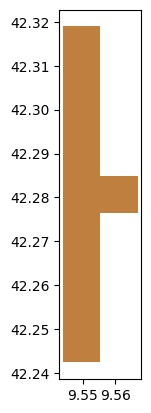

In [34]:
_,ax = plt.subplots()

matches.geometry[:10].plot(ax=ax,color=[0,1,0,0.5])
matches["preserved_geometry"][:10].plot(ax=ax,color=[1,0,0,0.5])

In [35]:
import pandas as pd

expected_to_new = pd.DataFrame(data={
    "index_new": matches.index, 
    "index_expected": matches["index_right"]})
expected_to_new.set_index(expected_to_new["index_expected"],inplace=True)
expected_to_new.drop(columns=["index_expected"],inplace=True)
expected_to_new

,index_new
index_expected,
603563,603563
603562,603562
603561,603561
603560,603560
603559,603559
...,...
4,4
3,3
2,2


In [36]:
expected_joined = expected.join(
    other=expected_to_new,
    how="inner"
)
expected_joined.set_index("index_new", inplace=True)
expected_joined.sort_index(inplace=True)
expected_joined


,hedgerows,aez_class,thz_class,mst_class,fold,plot_color,quadrant,sixteenth,tile,geometry
index_new,,,,,,,,,,
0,"LINESTRING (-5.116648 48.460143, -5.116593 48....","Sub-tropics, mod. cool; sub-humid, with soil/t...","TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],0,0,-1,"POLYGON ((-5.11665 48.45542, -5.10515 48.45542..."
1,"MULTILINESTRING ((-5.091588 48.455593, -5.0915...","Sub-tropics, mod. cool; sub-humid, no soil/ter...","TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],0,0,-1,"POLYGON ((-5.09365 48.45542, -5.08215 48.45542..."
2,"MULTILINESTRING ((-5.080938 48.458186, -5.0812...","Sub-tropics, mod. cool; sub-humid, no soil/ter...","TRC4: Subtropics, moderately cool",225-270 days,2,[0.58039216 0.40392157 0.74117647 1. ],0,0,-1,"POLYGON ((-5.08215 48.45542, -5.07065 48.45542..."
3,"LINESTRING (-4.783251 48.365696, -4.783193 48....",Land with severe soil/terrain limitations,"TRC5: Subtropics, cool",270-365 days,2,[0.58039216 0.40392157 0.74117647 1. ],0,0,6,"POLYGON ((-4.79469 48.36383, -4.78319 48.36383..."
4,"MULTILINESTRING ((-4.783604 48.409114, -4.7835...","Sub-tropics, cool; humid, with soil/terrain li...","TRC5: Subtropics, cool",270-365 days,2,[0.58039216 0.40392157 0.74117647 1. ],0,0,6,"POLYGON ((-4.79469 48.40201, -4.78319 48.40201..."
...,...,...,...,...,...,...,...,...,...,...
603559,"MULTILINESTRING ((9.545569 42.290445, 9.545759...","Sub-tropics, mod. cool; sub-humid, no soil/ter...","TRC4: Subtropics, moderately cool",225-270 days,0,[0.83921569 0.15294118 0.15686275 1. ],3,3,-1,"POLYGON ((9.54386 42.28494, 9.55536 42.28494, ..."
603560,"MULTILINESTRING ((9.544712 42.301154, 9.54485 ...","Sub-tropics, mod. cool; sub-humid, no soil/ter...","TRC4: Subtropics, moderately cool",225-270 days,0,[0.83921569 0.15294118 0.15686275 1. ],3,3,-1,"POLYGON ((9.54386 42.29345, 9.55536 42.29345, ..."
603561,"MULTILINESTRING ((9.544419 42.310455, 9.544564...","Sub-tropics, mod. cool; sub-humid, no soil/ter...","TRC4: Subtropics, moderately cool",225-270 days,0,[0.83921569 0.15294118 0.15686275 1. ],3,3,-1,"POLYGON ((9.54386 42.30195, 9.55536 42.30195, ..."


In [37]:
import shapely

# Geometry-aware column comparison. Raw `==` on geometries/WKT demands
# bit-identical coordinates AND identical vertex order, so it reports ~0
# for geometry written by different toolchains. Instead compare canonical
# forms (shapely.normalize fixes ring start/winding and multipart order)
# with a small tolerance: 1e-9 deg (~0.1 mm) absorbs reprojection float
# drift on patch polygons; 1e-5 deg (~1 m) absorbs the legacy asset's
# 6-decimal WKT rounding on hedgerows.
GEOM_TOLS = {"geometry": 1e-9, "hedgerows": 1e-5}

for col in new.columns:
    if col not in expected_joined.columns:
        continue
    ex_col = expected_joined[col].reindex(new.index)
    new_col = new[col]

    if col in GEOM_TOLS:
        ex_g = ex_col.values if col == "geometry" else shapely.from_wkt(ex_col.values)
        new_g = new_col.values if col == "geometry" else shapely.from_wkt(new_col.values)
        check = shapely.equals_exact(
            shapely.normalize(ex_g), shapely.normalize(new_g),
            tolerance=GEOM_TOLS[col],
        )
        num_true = int(check.sum())
    else:
        check = (ex_col == new_col)
        num_true = len(check[check == True])
    print(f"For column {col}: {(num_true / len(check)):.4f} match")

For column geometry: 1.0000 match
For column hedgerows: 1.0000 match
For column fold: 1.0000 match
For column tile: 1.0000 match
For column aez_class: 1.0000 match
For column mst_class: 1.0000 match
For column thz_class: 1.0000 match
